Load all 5 cities

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

BASE = "C:/Users/nikes/OneDrive/Desktop/Beginner-to-Architect/aiguard/airguard-uk/airguard-uk/data"

cities = {
    'MY1':  'London',
    'BIRR': 'Birmingham',
    'MAN3': 'Manchester',
    'NEWC': 'Newcastle',
    'CARD': 'Cardiff',
}

dfs = []
for site_id, name in cities.items():
    df = pd.read_csv(f"{BASE}/{name}/merged/{site_id}_merged.csv",
                     parse_dates=['datetime'])
    dfs.append(df)

data = pd.concat(dfs, ignore_index=True)
data = data.sort_values(['city','datetime']).reset_index(drop=True)

print(f"Total rows: {len(data):,}")
print(f"Date range: {data['datetime'].min()} → {data['datetime'].max()}")
print(data.groupby('city').size())

Total rows: 175,320
Date range: 2021-01-01 01:00:00 → 2025-01-01 00:00:00
city
BIRR    35064
CARD    35064
MAN3    35064
MY1     35064
NEWC    35064
dtype: int64


Summary statistics

In [15]:
print(data.groupby('city')[['NO2','PM2.5','PM10','O3']].mean().round(2))

        NO2  PM2.5   PM10     O3
city                            
BIRR  30.65   8.24  15.31  41.38
CARD  15.67   9.01  14.03  52.41
MAN3  27.95   8.90  15.36  38.96
MY1   41.07  11.23  18.44  29.22
NEWC  23.46   6.67  12.26  46.18


Missing value heatmap

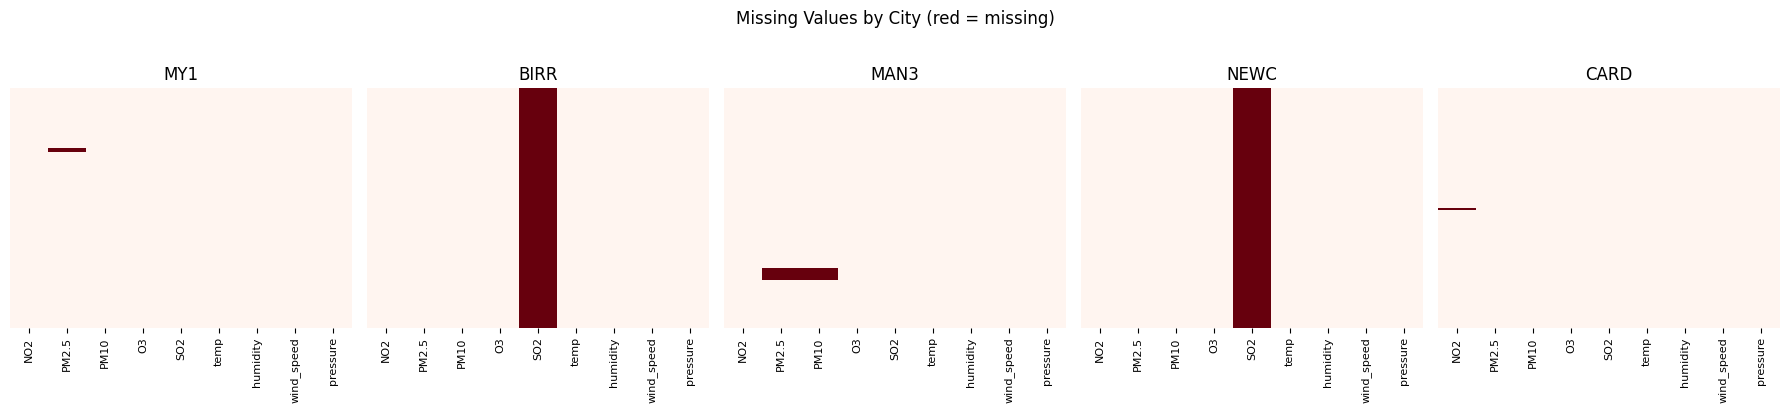

In [16]:
fig, axes = plt.subplots(1, 5, figsize=(18, 4))

for i, city in enumerate(cities):
    city_df = data[data['city'] == city][['NO2','PM2.5','PM10','O3','SO2','temp','humidity','wind_speed','pressure']]
    sns.heatmap(city_df.isna(), ax=axes[i], cbar=False,
                yticklabels=False, cmap='Reds')
    axes[i].set_title(city)
    axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=90, fontsize=8)

plt.suptitle('Missing Values by City (red = missing)', y=1.02)
plt.tight_layout()
plt.savefig(f"{BASE}/../plots/missing_values.png", bbox_inches='tight')
plt.show()

Missing Values:

Clean picture. Birmingham and Newcastle have full SO2 columns missing (the dark red blocks) — expected, no equipment at those stations. Manchester has a short PM2.5/PM10 gap — a monitor was likely offline for a few weeks. Everything else is essentially complete.

NO2 distribution

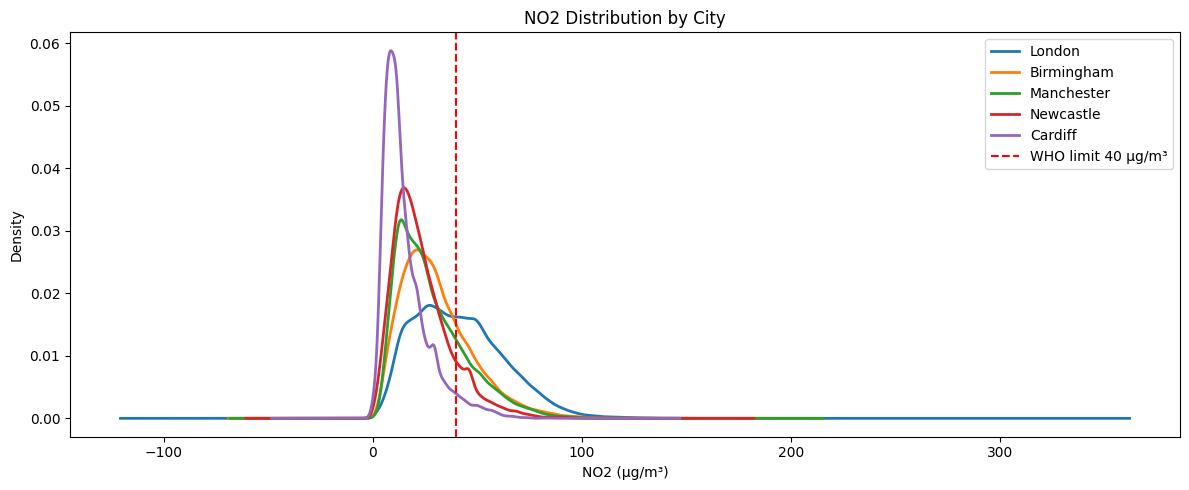

In [17]:
plt.figure(figsize=(12, 5))
for site_id, name in cities.items():
    data[data['city'] == site_id]['NO2'].dropna().plot(
        kind='kde', label=name, linewidth=2)

plt.axvline(40, color='red', linestyle='--', linewidth=1.5, label='WHO limit 40 µg/m³')
plt.xlabel('NO2 (µg/m³)')
plt.title('NO2 Distribution by City')
plt.legend()
plt.tight_layout()
plt.savefig(f"{BASE}/../plots/no2_distribution.png")
plt.show()

NO2 Distribution:

You have negative NO2 values — the x-axis goes to -100. This is instrument noise that wasn't clipped properly during your merge. You need to clip all pollutant columns to 0 in Phase 5 before training. London's distribution has a long right tail showing occasional very high pollution events.

Rush hour pattern

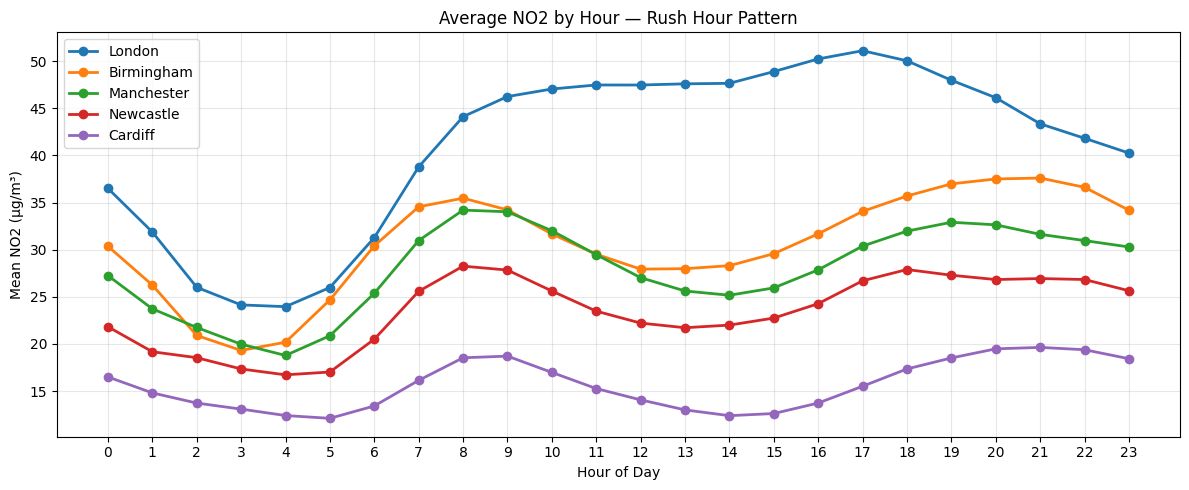

In [18]:
data['hour'] = data['datetime'].dt.hour
hourly = data.groupby(['city','hour'])['NO2'].mean().reset_index()

plt.figure(figsize=(12, 5))
for site_id, name in cities.items():
    subset = hourly[hourly['city'] == site_id]
    plt.plot(subset['hour'], subset['NO2'], marker='o', label=name, linewidth=2)

plt.xlabel('Hour of Day')
plt.ylabel('Mean NO2 (µg/m³)')
plt.title('Average NO2 by Hour — Rush Hour Pattern')
plt.xticks(range(0, 24))
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f"{BASE}/../plots/no2_by_hour.png")
plt.show()

Rush Hour Pattern:

London shows a clear double peak — rising sharply at 07:00, staying elevated through the afternoon, peaking at 17:00 (51 µg/m³). Cardiff is flat and low throughout. This hour_of_day feature will be one of your strongest predictors in Phase 5.

Seasonal pattern

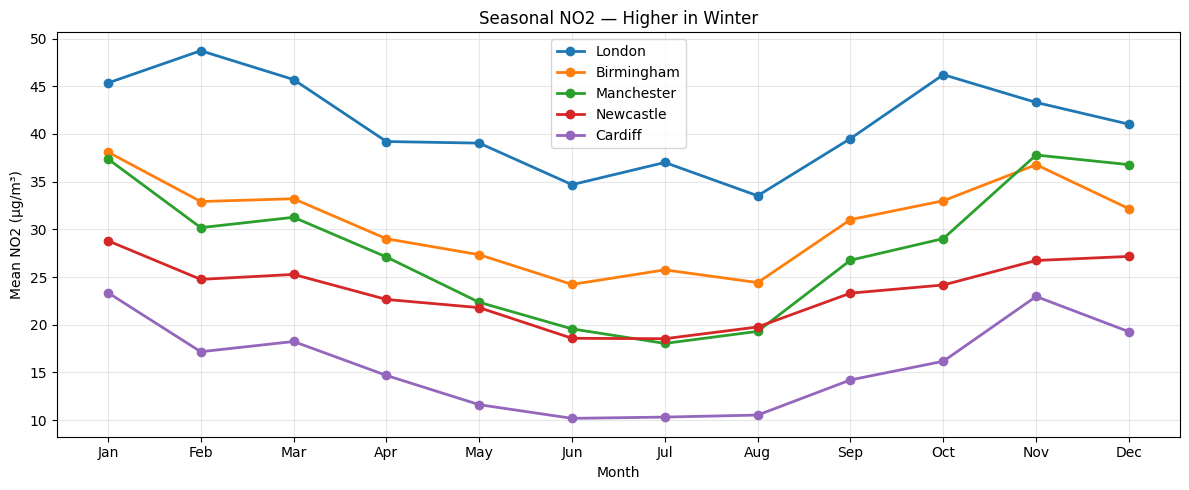

In [19]:
data['month'] = data['datetime'].dt.month
monthly = data.groupby(['city','month'])['NO2'].mean().reset_index()

plt.figure(figsize=(12, 5))
for site_id, name in cities.items():
    subset = monthly[monthly['city'] == site_id]
    plt.plot(subset['month'], subset['NO2'], marker='o', label=name, linewidth=2)

plt.xlabel('Month')
plt.ylabel('Mean NO2 (µg/m³)')
plt.title('Seasonal NO2 — Higher in Winter')
plt.xticks(range(1,13), ['Jan','Feb','Mar','Apr','May','Jun',
                          'Jul','Aug','Sep','Oct','Nov','Dec'])
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f"{BASE}/../plots/no2_seasonal.png")
plt.show()

Seasonal Pattern:

Strong winter peak across all cities — London hits 49 µg/m³ in February, drops to 34 µg/m³ in August. This is caused by cold stable air trapping pollution near the ground in winter. Your month feature will capture this seasonal cycle.

Correlation heatmap

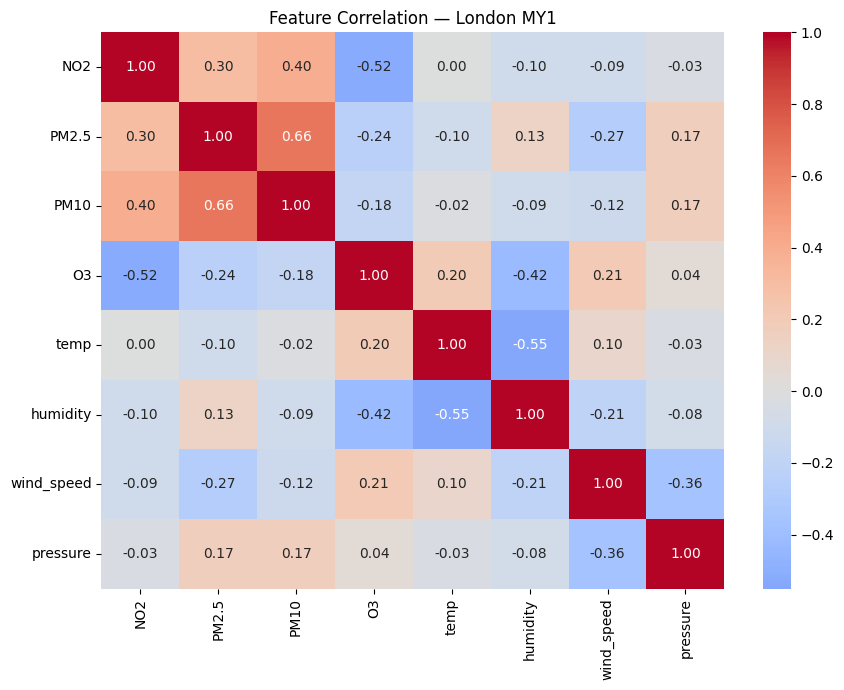

In [20]:
london = data[data['city'] == 'MY1'][
    ['NO2','PM2.5','PM10','O3','temp','humidity','wind_speed','pressure']
].dropna()

plt.figure(figsize=(9, 7))
sns.heatmap(london.corr().round(2), annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Feature Correlation — London MY1')
plt.tight_layout()
plt.savefig(f"{BASE}/../plots/correlation_heatmap.png")
plt.show()

Correlation Heatmap
Three standout findings:

- O3 and NO2 are negatively correlated (-0.52) — confirms the chemistry above
- Wind speed reduces PM2.5 (-0.27) — dispersal effect working as expected
- Humidity and temperature are negatively correlated (-0.55) — cold damp days vs warm dry days. All of these give your XGBoost model real signal to work with.

City comparison bar chart

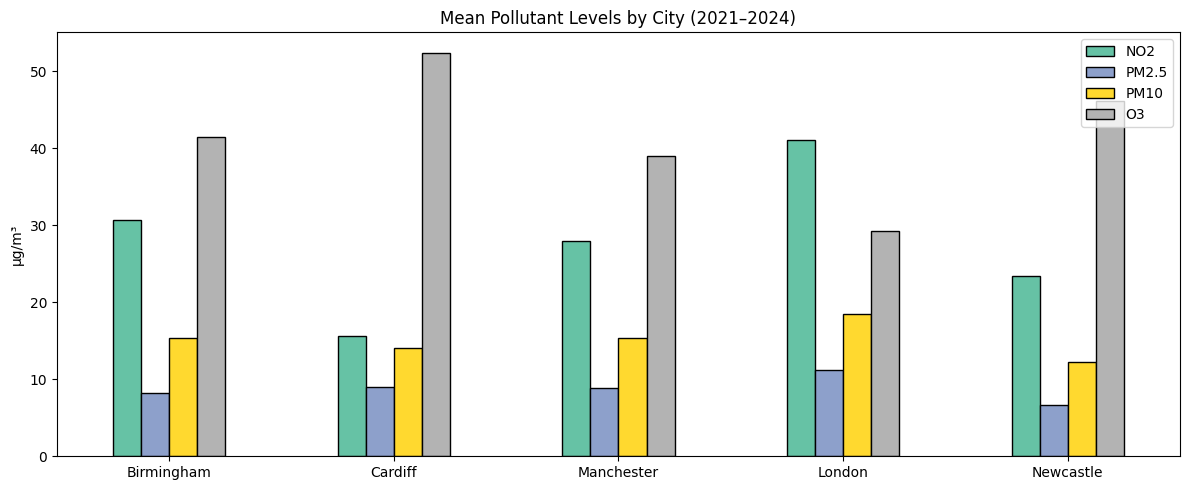

In [21]:
city_labels = {v: k for k, v in cities.items()}
means = data.groupby('city')[['NO2','PM2.5','PM10','O3']].mean()
means.index = [cities[c] for c in means.index]

means.plot(kind='bar', figsize=(12, 5), colormap='Set2', edgecolor='black')
plt.title('Mean Pollutant Levels by City (2021–2024)')
plt.ylabel('µg/m³')
plt.xticks(rotation=0)
plt.legend(loc='upper right')
plt.tight_layout()
plt.savefig(f"{BASE}/../plots/city_comparison.png")
plt.show()

City Comparison:

London has the highest NO2 (41 µg/m³) — above the WHO guideline of 40. Cardiff has the highest O3 (52 µg/m³) despite the lowest NO2, which makes chemical sense — NO2 actually suppresses ozone, so cleaner cities have more of it. This is a real atmospheric chemistry pattern your model needs to learn.